In [1]:
# import things
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from lo_tools import Lfun

import sys
from pathlib import Path

Ldir = Lfun.Lstart()

In [2]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "./stations/" + filename_lo
    filepath_ssc = "./stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [3]:
# read in observational data for each station
data_obs = pd.read_pickle( Ldir['LOo'] / 'obsmod'/ 'combined_bottle_2014_cas7_t1_x11ab_ssc_ssmpnnl.pkl')
data_obs = data_obs["obs"]

# ensure datatime format 
data_obs["time"] = pd.to_datetime(data_obs["time"])


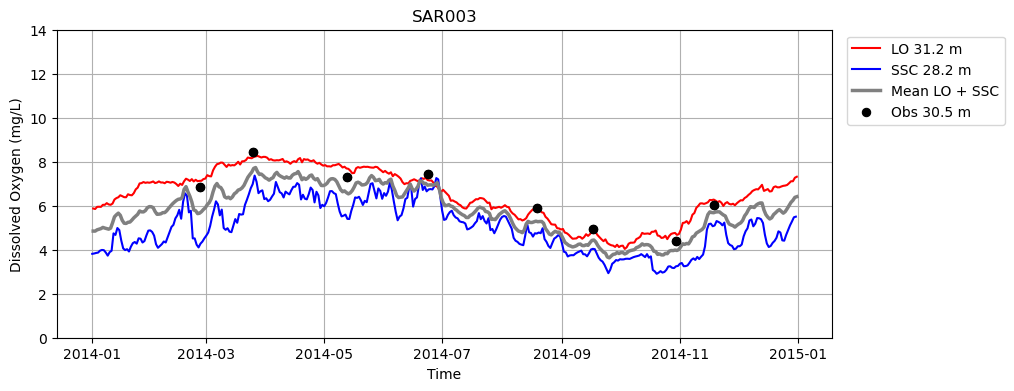

In [ ]:
station = "SAR003"

# Variables
varname_ssc = "dissolved_oxygen"
varname_lo = "oxygen"
varname_obs = "DO"

ds_ssc = data_ssc[station]
ds_lo = data_lo[station]
ds_obs = data_obs[data_obs["name"] == station]

# Target bottom depth
bottom_depth = -30.5

# ------------------------------------------------------------
# Find SSC layer closest to -30.5 m
# ------------------------------------------------------------
ssc_depths = -ds_ssc["deptht"].values
ssc_ind = np.argmin(np.abs(ssc_depths - bottom_depth))

ssc_model_depth = ssc_depths[ssc_ind]
ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)

# ------------------------------------------------------------
# Find LO layer closest to -30.5 m
# ------------------------------------------------------------
lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values
lo_ind = np.argmin(np.abs(lo_depths - bottom_depth))

lo_model_depth = lo_depths[lo_ind]
ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

# ------------------------------------------------------------
# Convert oxygen to mg/L
# ------------------------------------------------------------
lo_time = ds_lo_depth["ocean_time"].values
lo_do = ds_lo_depth[varname_lo].values * 0.032

ssc_time = ds_ssc_depth["time_counter"].values
ssc_do = ds_ssc_depth[varname_ssc].values * 0.032

# ------------------------------------------------------------
# Interpolate SSC onto LO time grid
# ------------------------------------------------------------
ssc_do_interp = np.interp(
    lo_time.astype("datetime64[s]").astype("int64"),
    ssc_time.astype("datetime64[s]").astype("int64"),
    ssc_do
)

# Mean of LO and SSC
mean_do = (lo_do + ssc_do_interp) / 2

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------
ds_obs_depth = ds_obs[np.isclose(ds_obs["z"], bottom_depth)]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

# LO
plt.plot(
    lo_time,
    lo_do,
    color="red",
    linewidth=1.5,
    label=f"LO {abs(lo_model_depth):.1f} m"
)

# SSC
plt.plot(
    ssc_time,
    ssc_do,
    color="blue",
    linewidth=1.5,
    label=f"SSC {abs(ssc_model_depth):.1f} m"
)

# Mean
plt.plot(
    lo_time,
    mean_do,
    color="grey",
    linewidth=2.5,
    label="Mean"
)

# Observations
plt.scatter(
    ds_obs_depth["time"],
    ds_obs_depth[varname_obs] * 0.032,
    color="black",
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
    label=f"Obs {abs(bottom_depth):.1f} m"
)

plt.title(f"{station}")
plt.ylim(0, 14)
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid()

plt.show()